---
## 1. Environment Setup & Schema Audit


In [8]:
import os
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
DATASET_PATH = DATASET_ROOT / "hf" / "merrec"
OUTPUT_DIR   = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


# ── DuckDB ────────────────────────────────────────────────────────────────────
con = duckdb.connect(database=":memory:")

# Core execution settings
con.execute("PRAGMA threads=6")                     # reduce from 10 → more stable
con.execute("PRAGMA memory_limit='20GB'")

# Temp spill configuration (THIS FIXES YOUR ERROR)
TMP_DIR = DATASET_ROOT / "duckdb_tmp"
TMP_DIR.mkdir(exist_ok=True)

con.execute(f"SET temp_directory='{TMP_DIR}'")
con.execute("PRAGMA max_temp_directory_size='50GB'")

# Reduce memory overhead in aggregations
con.execute("SET preserve_insertion_order=false")

con.execute("PRAGMA max_temp_directory_size='500GB'")

con.execute(f"""
CREATE VIEW merrec AS
SELECT *
FROM read_parquet('{DATASET_PATH}/**/*.parquet')
""")

print("View created successfully.")
print("Dataset path:", DATASET_PATH)


View created successfully.
Dataset path: /Volumes/T5 EVO/hf/merrec


In [9]:
# ── Plot style — clean white academic theme ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    font_scale=1.05,
    rc={
        "figure.facecolor":      "white",
        "axes.facecolor":        "white",
        "axes.edgecolor":        "#CCCCCC",
        "axes.labelcolor":       "#1A1A1A",
        "axes.labelsize":        11,
        "axes.titlesize":        13,
        "axes.titlecolor":       "#1A1A1A",
        "axes.titlepad":         14,
        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "grid.color":            "#E8E8E8",
        "grid.linewidth":        0.7,
        "xtick.color":           "#444444",
        "ytick.color":           "#444444",
        "xtick.labelsize":       9,
        "ytick.labelsize":       9,
        "text.color":            "#1A1A1A",
        "font.family":           "DejaVu Sans",
        "legend.facecolor":      "white",
        "legend.edgecolor":      "#CCCCCC",
        "legend.fontsize":       9,
        "legend.framealpha":     0.9,
        "savefig.facecolor":     "white",
        "savefig.dpi":           180,
        "savefig.bbox":          "tight",
        "figure.dpi":            120,
    }
)

# Refined academic palette — works well on white
PALETTE = [
    "#2E6FD9",  # blue
    "#E05C3A",  # red-orange
    "#3DA854",  # green
    "#8B52C4",  # purple
    "#D49A1A",  # amber
    "#2AAFB8",  # teal
    "#C44D8A",  # pink
    "#6B7280",  # slate
    "#1A8C5B",  # forest green
    "#D16B1F",  # burnt orange
]

def save(name: str):
    """Apply tight layout, save to OUTPUT_DIR, and display inline."""
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=180, bbox_inches="tight",
                facecolor="white")
    plt.show()
    print(f"  saved → eda_outputs/{name}.png")



In [10]:
# ── Schema inspection ────────────────────────────────────────────────────────
schema = con.execute("DESCRIBE merrec").df()
print("Dataset schema:")
display(schema)


Dataset schema:


,column_name,column_type,null,key,default,extra
0,user_id,BIGINT,YES,None,None,None
1,stime,TIMESTAMP,YES,None,None,None
2,session_id,VARCHAR,YES,None,None,None
3,sequence_id,VARCHAR,YES,None,None,None
4,sequence_length,BIGINT,YES,None,None,None
5,event_id,VARCHAR,YES,None,None,None
6,item_id,BIGINT,YES,None,None,None
7,product_id,VARCHAR,YES,None,None,None
8,name,VARCHAR,YES,None,None,None
9,price,DOUBLE,YES,None,None,None


---
## 2. Dataset-Level Summary Statistics

Before drilling into individual dimensions, we establish a single-query global summary that captures:
- Scale (events, users, items, sessions)
- Temporal extent (earliest / latest event, total span in days)
- Missing-value counts per column — critical for downstream imputation decisions


In [11]:
summary = con.execute("""
SELECT
    COUNT(*)                                   AS total_events,
    APPROX_COUNT_DISTINCT(user_id)             AS approx_users,
    APPROX_COUNT_DISTINCT(item_id)             AS approx_items,
    APPROX_COUNT_DISTINCT(session_id)          AS approx_sessions,
    COUNT(DISTINCT event_id)                   AS event_types,
    MIN(stime)                                 AS earliest,
    MAX(stime)                                 AS latest,
    DATEDIFF('day', MIN(stime), MAX(stime))    AS span_days,
    COUNT(*) FILTER (WHERE price    IS NULL)   AS null_price,
    COUNT(*) FILTER (WHERE c0_name  IS NULL)   AS null_c0,
    COUNT(*) FILTER (WHERE c1_name  IS NULL)   AS null_c1,
    COUNT(*) FILTER (WHERE c2_name  IS NULL)   AS null_c2,
    COUNT(*) FILTER (WHERE user_id  IS NULL)   AS null_user,
    COUNT(*) FILTER (WHERE item_id  IS NULL)   AS null_item
FROM merrec
""").df()

print("=== Global Dataset Summary ===")
display(summary.T.rename(columns={0: "value"}))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Global Dataset Summary ===


,value
total_events,1268092738
approx_users,5764026
approx_items,78539386
approx_sessions,23671282
event_types,6
earliest,2023-05-01 00:00:00
latest,2023-10-31 00:00:00
span_days,183
null_price,0
null_c0,0


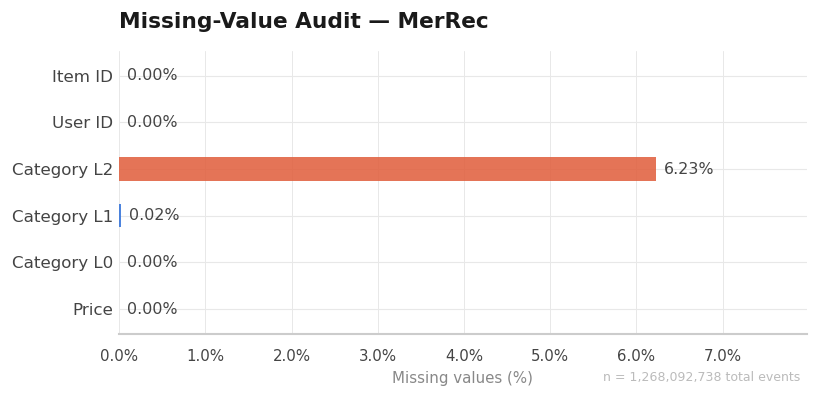

  saved → eda_outputs/01_missing_value_audit.png


In [10]:
# ── Missing-value audit ───────────────────────────────────────────────────────
null_cols   = ["null_price", "null_c0", "null_c1", "null_c2", "null_user", "null_item"]
null_labels = ["Price", "Category L0", "Category L1", "Category L2", "User ID", "Item ID"]
null_vals   = summary[null_cols].values.flatten()
total       = summary["total_events"].values[0]
null_pct    = null_vals / total * 100

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.set_title("Missing-Value Audit — MerRec",
             fontsize=13, fontweight="bold", pad=14, loc="left")

for i, (label, pct) in enumerate(zip(null_labels, null_pct)):
    color = "#E05C3A" if pct > 1 else PALETTE[0]
    ax.barh(i, pct, color=color, height=0.5,
            edgecolor="none", alpha=0.85)

    # value label outside bar
    ax.text(pct + max(null_pct) * 0.015, i,
            f"{pct:.2f}%", va="center", ha="left",
            fontsize=9.5, color="#444444")

ax.set_yticks(range(len(null_labels)))
ax.set_yticklabels(null_labels, fontsize=10)
ax.set_xlabel("Missing values (%)", fontsize=9, color="#888888")
ax.set_xlim(0, max(null_pct) * 1.28)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# Match the long-tail plot spine style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", linewidth=0.6, color="#E8E8E8")
ax.set_axisbelow(True)

# Subtle footnote
ax.text(0.99, -0.18, f"n = {total:,.0f} total events",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=7.5, color="#BBBBBB")

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
save("01_missing_value_audit")

---
## 3. User-Side Distributions

This section characterises the user population across five dimensions:



In [7]:
# ── Fetch user event counts (ec) ─────────────────────────────────────────────
events_per_user = con.execute("""
    SELECT user_id, COUNT(*) AS event_count
    FROM merrec
    GROUP BY user_id
""").fetch_arrow_table()
ec = np.array(events_per_user["event_count"])

# ── Fetch item event counts (ic) ─────────────────────────────────────────────
events_per_item = con.execute("""
    SELECT item_id, COUNT(*) AS event_count
    FROM merrec
    GROUP BY item_id
""").fetch_arrow_table()
ic = np.array(events_per_item["event_count"])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

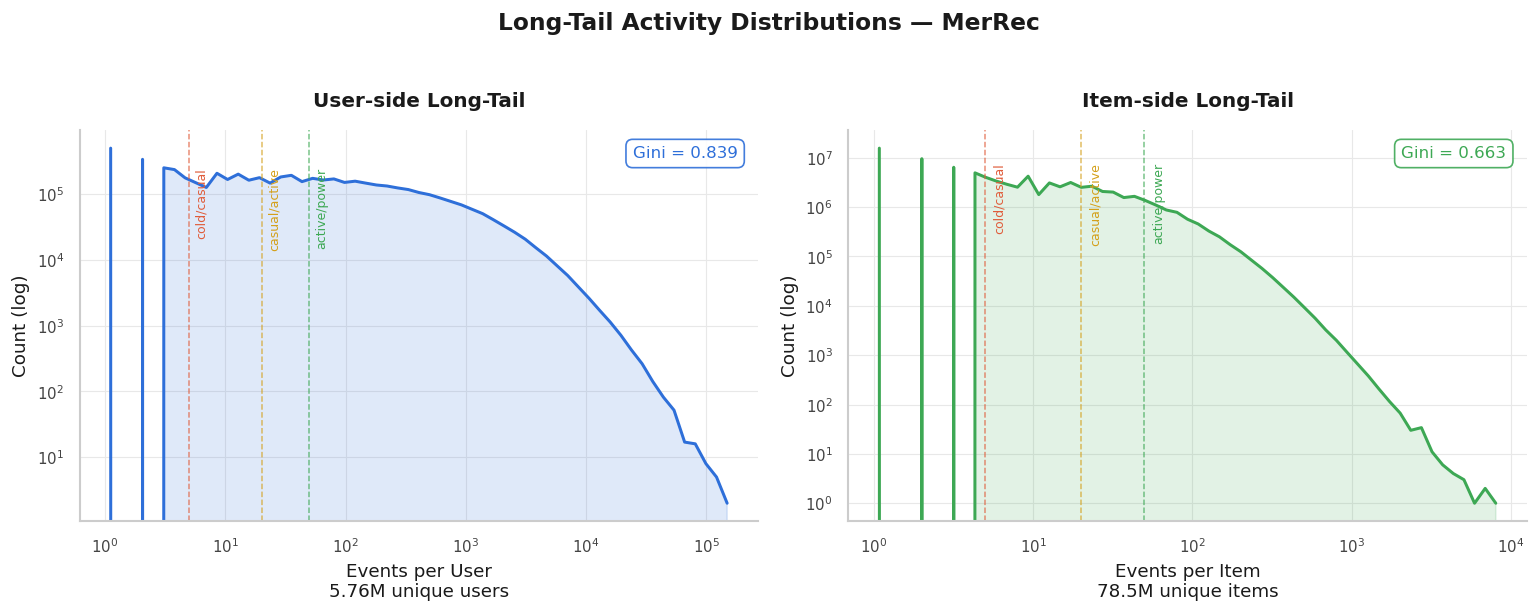

  saved → eda_outputs/02a_events_per_user.png


In [9]:
# ── 3a. Events per user (left) vs Events per item (right) ────────────────────
# NOTE: item counts (ic) must already be computed — run Section 4a query first,
# or move this cell after Section 4a.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Long-Tail Activity Distributions — MerRec",
             fontsize=14, fontweight="bold", y=1.02)

for ax, data, label, color, subtitle, gini_label in zip(
    axes,
    [ec, ic],
    ["Events per User", "Events per Item"],
    [PALETTE[0], PALETTE[2]],
    ["5.76M unique users", "78.5M unique items"],
    ["User-side", "Item-side"],
):
    bins = np.logspace(np.log10(max(data.min(), 1)),
                       np.log10(data.max()), 60)
    counts, edges = np.histogram(data, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2

    axes_list = ax
    ax.fill_between(centers, counts, alpha=0.15, color=color)
    ax.plot(centers, counts, color=color, linewidth=1.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Count (log)", fontsize=11)
    ax.set_title(f"{gini_label} Long-Tail", fontsize=12, fontweight="bold")
    ax.set_xlabel(f"{label}\n{subtitle}", fontsize=11)

    # Gini annotation
    n = len(data)
    s = np.sort(data.astype(float))
    gini_val = (2 * np.sum(np.arange(1, n+1) * s) / (n * s.sum())) - (n+1)/n
    ax.text(0.97, 0.96, f"Gini = {gini_val:.3f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, color=color,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=color, alpha=0.9))

    # Tier boundary lines
    for xv, lbl, c in [
        (5,  "cold/casual",   "#E05C3A"),
        (20, "casual/active", "#D4A01A"),
        (50, "active/power",  "#3DA854"),
    ]:
        ax.axvline(xv, color=c, linewidth=0.9, linestyle="--", alpha=0.7)
        ax.text(xv * 1.12, counts.max() * 0.5, lbl,
                fontsize=7.5, color=c, rotation=90, va="top")

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
save("02a_events_per_user")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

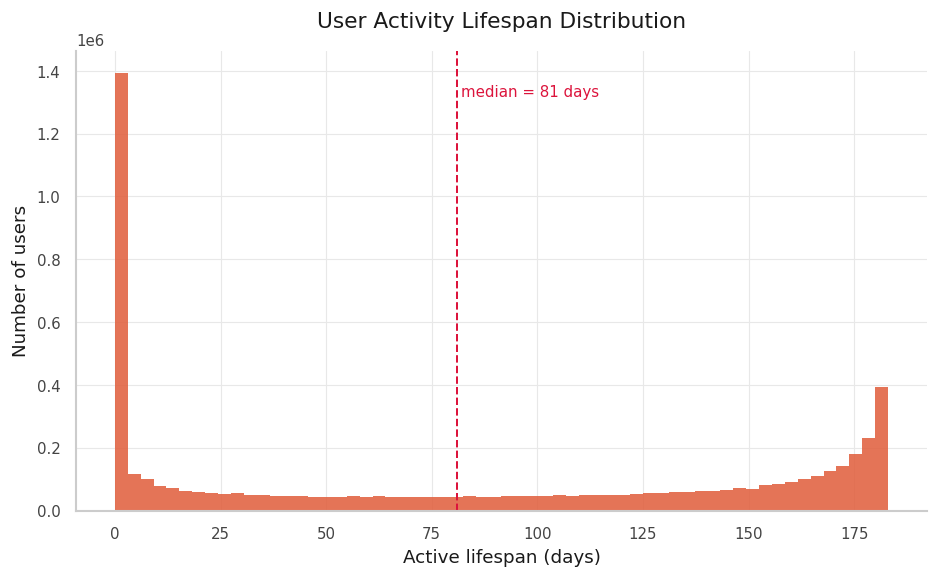

  saved → eda_outputs/02b_user_lifespan.png


In [11]:
# ── 3b. User lifespan ─────────────────────────────────────────────────────────
lifespan = con.execute("""
    SELECT EXTRACT(EPOCH FROM (MAX(stime) - MIN(stime))) / 86400.0 AS days
    FROM merrec
    GROUP BY user_id
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lifespan["days"].dropna(), bins=60, color=PALETTE[1], edgecolor="none", alpha=0.85)
ax.set(xlabel="Active lifespan (days)",
       ylabel="Number of users",
       title="User Activity Lifespan Distribution")
med = lifespan["days"].median()
ax.axvline(med, color="crimson", linestyle="--", linewidth=1.2)
ax.text(med + 1, ax.get_ylim()[1] * 0.9, f"median = {med:.0f} days",
        color="crimson", fontsize=9)
save("02b_user_lifespan")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

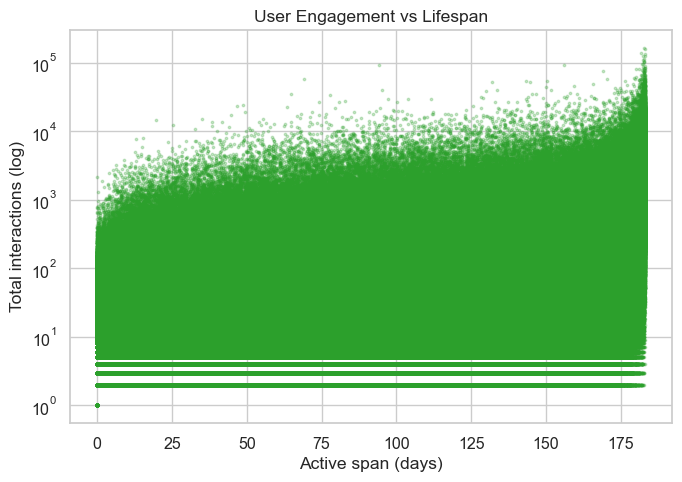

  ✓ saved → eda_outputs/02c_user_engagement_vs_lifespan.png


In [9]:
# ── 3c. Interactions vs lifespan ──────────────────────────────────────────────
engagement = con.execute("""
    SELECT
        COUNT(*) AS interactions,
        EXTRACT(EPOCH FROM (MAX(stime) - MIN(stime))) / 86400.0 AS span
    FROM merrec
    GROUP BY user_id
""").df()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(engagement["span"], engagement["interactions"],
           s=3, alpha=0.25, color=PALETTE[2], rasterized=True)
ax.set(yscale="log",
       xlabel="Active span (days)",
       ylabel="Total interactions (log)",
       title="User Engagement vs Lifespan")
save("02c_user_engagement_vs_lifespan")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

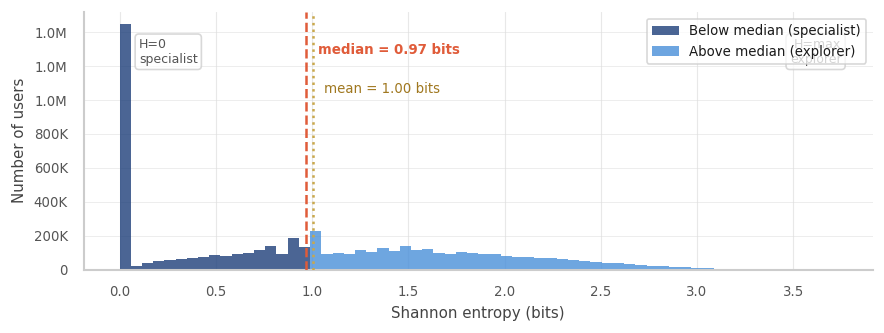

saved → 02d_user_category_entropy_transparent.png


In [15]:
# ── 3d. Category entropy per user — Poster Version (transparent) ──────────────
entropy_df = con.execute("""
    WITH uc AS (
        SELECT user_id, c0_name, COUNT(*) AS cnt
        FROM merrec
        WHERE c0_name IS NOT NULL
        GROUP BY user_id, c0_name
    ),
    totals AS (
        SELECT user_id, SUM(cnt) AS total FROM uc GROUP BY user_id
    )
    SELECT
        uc.user_id,
        -SUM((uc.cnt * 1.0 / t.total) * LOG2(uc.cnt * 1.0 / t.total)) AS entropy
    FROM uc JOIN totals t USING(user_id)
    GROUP BY uc.user_id
""").df()

entropy = entropy_df["entropy"].dropna()
med_e   = entropy.median()
mean_e  = entropy.mean()

# ── Poster-matched figure size ────────────────────────────────────────────────
# Right column = 0.48 * colwidth on A0 poster
# colwidth ≈ 0.463 * 841mm ≈ 389mm ≈ 15.3 inches
# 0.48 * 15.3 ≈ 7.35 inches wide
# height=7cm in pgfplots ≈ 2.75 inches
fig, ax = plt.subplots(figsize=(7.35, 2.75))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")

bins      = np.linspace(entropy.min(), entropy.max(), 65)
counts, _ = np.histogram(entropy, bins=bins)
centers   = (bins[:-1] + bins[1:]) / 2

# Below median — specialist (navy)
ax.bar(centers[centers <= med_e],
       counts[centers <= med_e],
       width=bins[1] - bins[0],
       color="#1E3F7A",
       alpha=0.80,
       edgecolor="none",
       label=f"Below median (specialist)")

# Above median — explorer (blue)
ax.bar(centers[centers > med_e],
       counts[centers > med_e],
       width=bins[1] - bins[0],
       color="#4A90D9",
       alpha=0.80,
       edgecolor="none",
       label=f"Above median (explorer)")

# Median line
ax.axvline(med_e, color="#E05C3A", linestyle="--",
           linewidth=1.5, zorder=5)
ax.text(med_e + 0.06,
        counts.max() * 0.88,
        f"median = {med_e:.2f} bits",
        color="#E05C3A", fontsize=8, fontweight="bold")

# Mean line
ax.axvline(mean_e, color="#C9A84C", linestyle=":",
           linewidth=1.5, zorder=5)
ax.text(mean_e + 0.06,
        counts.max() * 0.72,
        f"mean = {mean_e:.2f} bits",
        color="#A07820", fontsize=8)

# H=0 annotation
ax.text(0.07, 0.90,
        "H=0\nspecialist",
        transform=ax.transAxes,
        fontsize=7.5, color="#555555", va="top",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#CCCCCC",
                  alpha=0.75))

# H=max annotation
ax.text(0.96, 0.90,
        "H=max\nexplorer",
        transform=ax.transAxes,
        fontsize=7.5, color="#555555",
        va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#CCCCCC",
                  alpha=0.75))

# Axes styling
ax.set_xlabel("Shannon entropy (bits)", fontsize=9, color="#444444")
ax.set_ylabel("Number of users",        fontsize=9, color="#444444")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(colors="#555555", labelsize=8)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x/1e6):.1f}M"
                          if x >= 1e6 else f"{int(x/1e3)}K"
                          if x >= 1e3 else str(int(x))))

ax.legend(fontsize=8, framealpha=0.75,
          edgecolor="#CCCCCC", facecolor="white",
          loc="upper right")

ax.grid(axis="y", color="#DDDDDD", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout(pad=0.5)
plt.savefig(
    os.path.join(OUTPUT_DIR, "02d_user_category_entropy_transparent.png"),
    dpi=180,
    bbox_inches="tight",
    facecolor="none",
    transparent=True
)
plt.show()
print("saved → 02d_user_category_entropy_transparent.png")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

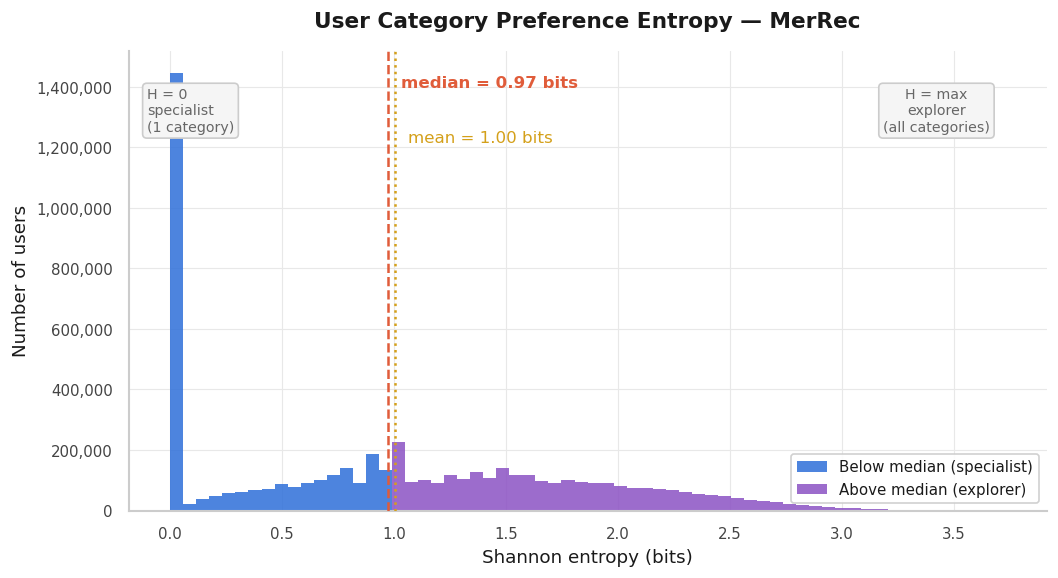

  saved → eda_outputs/02d_user_category_entropy.png


In [7]:
# ── 3d. Category entropy per user ────────────────────────────────────────────
entropy_df = con.execute("""
    WITH uc AS (
        SELECT user_id, c0_name, COUNT(*) AS cnt
        FROM merrec
        WHERE c0_name IS NOT NULL
        GROUP BY user_id, c0_name
    ),
    totals AS (
        SELECT user_id, SUM(cnt) AS total FROM uc GROUP BY user_id
    )
    SELECT
        uc.user_id,
        -SUM((uc.cnt * 1.0 / t.total) * LOG2(uc.cnt * 1.0 / t.total)) AS entropy
    FROM uc JOIN totals t USING(user_id)
    GROUP BY uc.user_id
""").df()

entropy = entropy_df["entropy"].dropna()
med_e   = entropy.median()
mean_e  = entropy.mean()

fig, ax = plt.subplots(figsize=(9, 5))

# Histogram with gradient-like color split at median
bins      = np.linspace(entropy.min(), entropy.max(), 65)
counts, _ = np.histogram(entropy, bins=bins)
centers   = (bins[:-1] + bins[1:]) / 2

ax.bar(centers[centers <= med_e], counts[centers <= med_e],
       width=bins[1] - bins[0], color=PALETTE[0],
       alpha=0.85, edgecolor="none", label="Below median (specialist)")
ax.bar(centers[centers > med_e], counts[centers > med_e],
       width=bins[1] - bins[0], color=PALETTE[3],
       alpha=0.85, edgecolor="none", label="Above median (explorer)")

# Median line
ax.axvline(med_e, color="#E05C3A", linestyle="--",
           linewidth=1.5, zorder=5)
ax.text(med_e + 0.06, ax.get_ylim()[1] * 0.92,
        f"median = {med_e:.2f} bits",
        color="#E05C3A", fontsize=10, fontweight="bold")

# Mean line
ax.axvline(mean_e, color="#D4A01A", linestyle=":",
           linewidth=1.5, zorder=5)
ax.text(mean_e + 0.06, ax.get_ylim()[1] * 0.80,
        f"mean = {mean_e:.2f} bits",
        color="#D4A01A", fontsize=10)

# Annotations for interpretation
ax.text(0.02, 0.92, "H = 0\nspecialist\n(1 category)",
        transform=ax.transAxes, fontsize=8.5,
        color="#666666", va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5",
                  edgecolor="#CCCCCC"))
ax.text(0.88, 0.92, "H = max\nexplorer\n(all categories)",
        transform=ax.transAxes, fontsize=8.5,
        color="#666666", va="top", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5",
                  edgecolor="#CCCCCC"))

ax.set_xlabel("Shannon entropy (bits)", fontsize=11)
ax.set_ylabel("Number of users", fontsize=11)
ax.set_title("User Category Preference Entropy — MerRec",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=9, framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))

plt.tight_layout()
save("02d_user_category_entropy")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

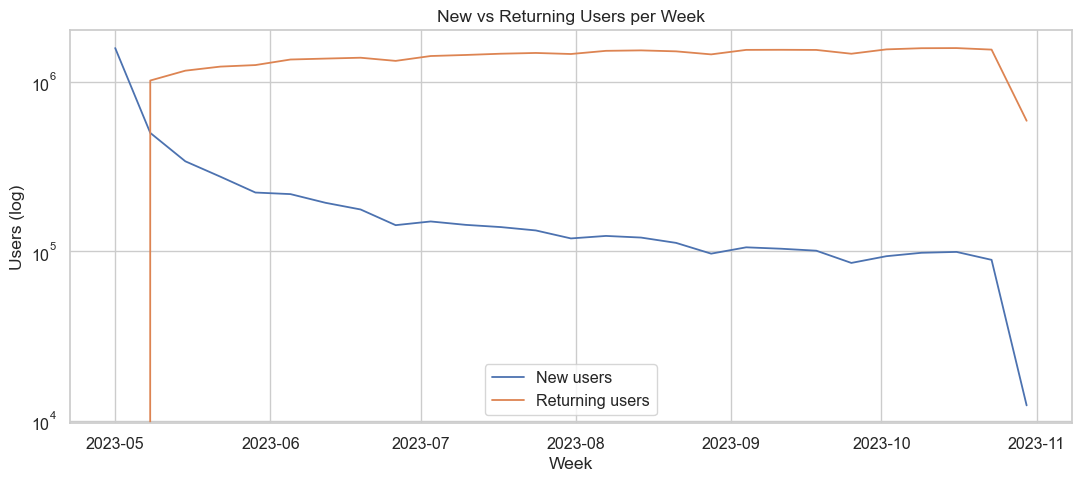

  ✓ saved → eda_outputs/02e_new_vs_returning_users.png


: 

In [ ]:
# ── 3e. New vs returning users (weekly) ──────────────────────────────────────
new_ret = con.execute("""
    WITH first_seen AS (
        SELECT user_id, MIN(DATE_TRUNC('week', stime)) AS first_week
        FROM merrec GROUP BY user_id
    ),
    weekly_users AS (
        SELECT DATE_TRUNC('week', stime) AS week, user_id
        FROM merrec GROUP BY week, user_id
    )
    SELECT
        wu.week,
        COUNT(*) FILTER (WHERE wu.week = fs.first_week) AS new_users,
        COUNT(*) FILTER (WHERE wu.week > fs.first_week)  AS returning_users
    FROM weekly_users wu
    JOIN first_seen fs USING(user_id)
    GROUP BY wu.week ORDER BY wu.week
""").df()

new_ret["week"] = pd.to_datetime(new_ret["week"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(new_ret["week"], new_ret["new_users"],       label="New users",      linewidth=1.3)
ax.plot(new_ret["week"], new_ret["returning_users"], label="Returning users", linewidth=1.3)
ax.set(yscale="log", xlabel="Week", ylabel="Users (log)",
       title="New vs Returning Users per Week")
ax.legend()
save("02e_new_vs_returning_users")


---
## 4. Item-Side Distributions

The item distribution analysis mirrors the user analysis and is equally important: in C2C marketplaces the item catalog is dynamic (sellers continuously add and remove listings), leading to strong temporal and popularity heterogeneity.



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

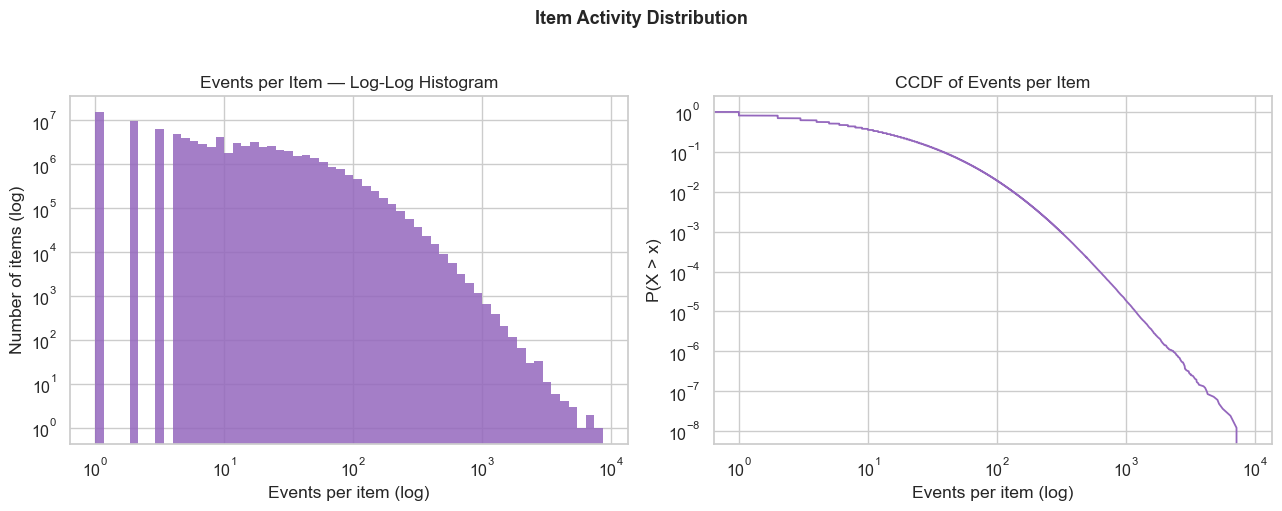

  ✓ saved → eda_outputs/03a_events_per_item.png


In [8]:
# ── 4a. Events per item ───────────────────────────────────────────────────────
events_per_item = con.execute("""
    SELECT item_id, COUNT(*) AS event_count
    FROM merrec
    GROUP BY item_id
""").fetch_arrow_table()

ic = np.array(events_per_item["event_count"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(ic, bins=np.logspace(0, np.log10(ic.max()), 60),
             color=PALETTE[4], edgecolor="none", alpha=0.85)
axes[0].set(xscale="log", yscale="log",
            xlabel="Events per item (log)",
            ylabel="Number of items (log)",
            title="Events per Item — Log-Log Histogram")

sorted_ic = np.sort(ic)
ccdf_i = 1.0 - np.arange(1, len(sorted_ic) + 1) / len(sorted_ic)
axes[1].plot(sorted_ic, ccdf_i, linewidth=1.3, color=PALETTE[4])
axes[1].set(xscale="log", yscale="log",
            xlabel="Events per item (log)",
            ylabel="P(X > x)",
            title="CCDF of Events per Item")

fig.suptitle("Item Activity Distribution", fontsize=13, fontweight="bold", y=1.02)
save("03a_events_per_item")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

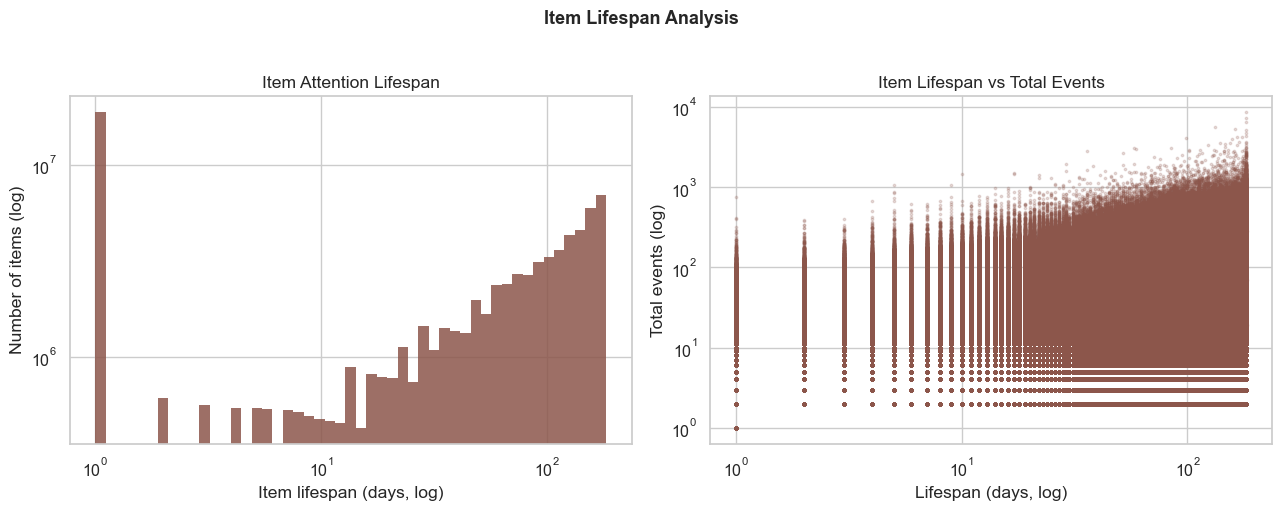

  ✓ saved → eda_outputs/03b_item_lifespan.png


In [6]:
# ── 4b. Item lifespan vs total events ────────────────────────────────────────
item_lifespan = con.execute("""
    SELECT
        item_id,
        COUNT(*) AS total_events,
        DATEDIFF('day', MIN(DATE(stime)), MAX(DATE(stime))) AS span_days
    FROM merrec
    GROUP BY item_id
""").df()

item_lifespan["span_days"] = item_lifespan["span_days"].clip(lower=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(
    item_lifespan["span_days"],
    bins=np.logspace(0, np.log10(item_lifespan["span_days"].max()), 50),
    color=PALETTE[5], edgecolor="none", alpha=0.85
)
axes[0].set(xscale="log", yscale="log",
            xlabel="Item lifespan (days, log)",
            ylabel="Number of items (log)",
            title="Item Attention Lifespan")

axes[1].scatter(item_lifespan["span_days"], item_lifespan["total_events"],
                s=3, alpha=0.2, color=PALETTE[5], rasterized=True)
axes[1].set(xscale="log", yscale="log",
            xlabel="Lifespan (days, log)",
            ylabel="Total events (log)",
            title="Item Lifespan vs Total Events")

fig.suptitle("Item Lifespan Analysis", fontsize=13, fontweight="bold", y=1.02)
save("03b_item_lifespan")


---
## 5. Session-Level Statistics

Sessions are the primary unit of short-term intent. Understanding session structure directly informs the research question: *how do short-term session dynamics compare to long-term user preferences in determining item relevance?*


In [3]:

summary = con.execute("""
    SELECT
        COUNT(*) AS n_sessions,
        AVG(session_len) AS avg_len,
        APPROX_QUANTILE(session_len, 0.5) AS median_len,
        MAX(session_len) AS max_len,

        AVG(duration_sec) AS avg_duration,
        APPROX_QUANTILE(duration_sec, 0.5) AS median_duration
    FROM (
        SELECT
            session_id,
            COUNT(*) AS session_len,
            DATEDIFF('second', MIN(stime), MAX(stime)) AS duration_sec
        FROM merrec
        GROUP BY session_id
    )
""").df()

print(f"Sessions computed: {len(summary):,}")
display(summary.describe().round(2))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sessions computed: 1


,n_sessions,avg_len,median_len,max_len,avg_duration,median_duration
count,1.0,1.00,1.0,1.0,1.00,1.0
mean,25864474.0,49.03,29.0,2882.0,880.85,740.0
std,NaN,NaN,NaN,NaN,NaN,NaN
min,25864474.0,49.03,29.0,2882.0,880.85,740.0
25%,25864474.0,49.03,29.0,2882.0,880.85,740.0
50%,25864474.0,49.03,29.0,2882.0,880.85,740.0
75%,25864474.0,49.03,29.0,2882.0,880.85,740.0
max,25864474.0,49.03,29.0,2882.0,880.85,740.0


In [ ]:
# ── Pre-compute session-level aggregates and save to SSD ─────────────────────

OUTPUT_PATH = Path("/Volumes/T5 EVO/hf/merrec/session_stats.parquet")

con.execute(f"""
COPY (
    SELECT
        session_id,
        user_id,
        COUNT(*)                                                        AS session_len,
        DATEDIFF('second', MIN(stime), MAX(stime))                     AS duration_sec,
        COUNT(DISTINCT item_id)                                         AS unique_items,
        COUNT(DISTINCT event_id)                                        AS event_types_used,
        COUNT(*) FILTER (WHERE event_id = 'item_view')                 AS views,
        COUNT(*) FILTER (WHERE event_id = 'buy_comp')                  AS purchases
    FROM merrec
    GROUP BY session_id, user_id
)
TO '{OUTPUT_PATH}'
(
    FORMAT PARQUET,
    COMPRESSION ZSTD,
    ROW_GROUP_SIZE 500000
)
""")

print(f"Saved session_stats to: {OUTPUT_PATH}")
print(f"File size: {OUTPUT_PATH.stat().st_size / 1024**2:.1f} MB")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
# ── Load session_stats from SSD (fast, no recompute) ─────────────────────────
OUTPUT_PATH = Path("/Volumes/T5 EVO/hf/merrec/session_stats.parquet")

session_stats = con.execute(f"""
    SELECT * FROM read_parquet('{OUTPUT_PATH}')
""").df()

print(f"Loaded {len(session_stats):,} sessions")

In [ ]:
# ── 5a. Session length distribution ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(session_stats["session_len"].clip(upper=200), bins=60,
             color=PALETTE[6], edgecolor="none", alpha=0.85)
axes[0].set(xlabel="Events per session (clipped at 200)",
            ylabel="Number of sessions",
            title="Session Length — Linear")

axes[1].hist(session_stats["session_len"],
             bins=np.logspace(0, np.log10(session_stats["session_len"].max()), 50),
             color=PALETTE[6], edgecolor="none", alpha=0.85)
axes[1].set(xscale="log", yscale="log",
            xlabel="Events per session (log)",
            ylabel="Number of sessions (log)",
            title="Session Length — Log-Log")

fig.suptitle("Session Length Distribution", fontsize=13, fontweight="bold", y=1.02)
save("04a_session_length")


In [ ]:
# ── 5b. Session duration ──────────────────────────────────────────────────────
dur_min = session_stats["duration_sec"].dropna() / 60

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dur_min.clip(upper=120), bins=60, color=PALETTE[7], edgecolor="none", alpha=0.85)
ax.set(xlabel="Session duration (minutes, clipped at 120)",
       ylabel="Number of sessions",
       title="Session Duration Distribution")
med_dur = dur_min.median()
ax.axvline(med_dur, color="crimson", linestyle="--", linewidth=1.2)
ax.text(med_dur + 0.5, ax.get_ylim()[1] * 0.9,
        f"median = {med_dur:.1f} min", color="crimson", fontsize=9)
save("04b_session_duration")


In [ ]:
# ── 5c. Unique items per session ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(session_stats["unique_items"].clip(upper=100), bins=60,
        color=PALETTE[8], edgecolor="none", alpha=0.85)
ax.set(xlabel="Unique items per session (clipped at 100)",
       ylabel="Number of sessions",
       title="Item Breadth per Session")
save("04c_items_per_session")


In [ ]:
# ── 5d. User session behaviour space ─────────────────────────────────────────
#
# Each point = one user. Axes: number of sessions vs average session length.
# This diagnostic view reveals whether users cluster into distinguishable
# behavioral modes (explorers, focused buyers, passive browsers) —
# a preview of the regime analysis in Layer 3.

user_session_agg = con.execute("""
    SELECT
        user_id,
        APPROX_COUNT_DISTINCT(session_id)                               AS num_sessions,
        (COUNT(*) * 1.0) / NULLIF(APPROX_COUNT_DISTINCT(session_id), 0) AS avg_session_len
    FROM merrec
    GROUP BY user_id
""").df()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(user_session_agg["num_sessions"], user_session_agg["avg_session_len"],
           s=4, alpha=0.25, color=PALETTE[9], rasterized=True)
ax.set(xscale="log", yscale="log",
       xlabel="Number of sessions (log)",
       ylabel="Avg session length (log)",
       title="User Session Behaviour Space\n(each point = one user)")
save("04d_user_session_behaviour")


---
## 6. Event & Funnel Analysis




FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

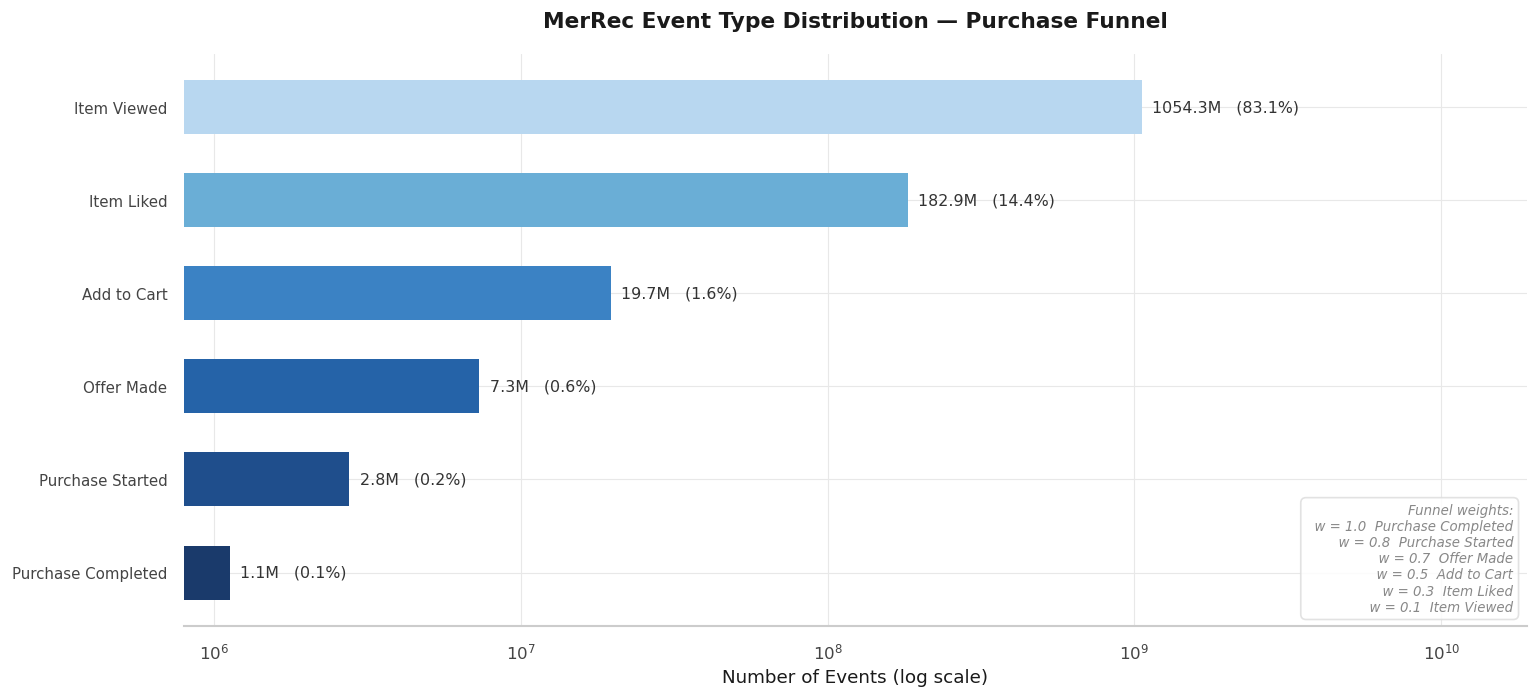

  saved → eda_outputs/05a_event_type_distribution.png


In [ ]:
# ── 6a. Event type distribution ──────────────────────────────────────────────
event_dist = con.execute("""
    SELECT event_id, COUNT(*) AS cnt
    FROM merrec
    GROUP BY event_id
    ORDER BY cnt DESC
""").df()

funnel_order = [
    "buy_comp",
    "buy_start",
    "offer_make",
    "item_add_to_cart_tap",
    "item_like",
    "item_view",
]
funnel_labels = {
    "buy_comp":              "Purchase Completed",
    "buy_start":             "Purchase Started",
    "offer_make":            "Offer Made",
    "item_add_to_cart_tap":  "Add to Cart",
    "item_like":             "Item Liked",
    "item_view":             "Item Viewed",
}
funnel_weights = {
    "buy_comp":             1.0,
    "buy_start":            0.8,
    "offer_make":           0.7,
    "item_add_to_cart_tap": 0.5,
    "item_like":            0.3,
    "item_view":            0.1,
}

event_dist = event_dist.set_index("event_id").reindex(funnel_order).reset_index()
event_dist["label"]  = event_dist["event_id"].map(funnel_labels)
event_dist["weight"] = event_dist["event_id"].map(funnel_weights)
event_dist["pct"]    = event_dist["cnt"] / event_dist["cnt"].sum() * 100

bar_colors = [
    "#1A3A6B",
    "#1F4E8C",
    "#2563A8",
    "#3B82C4",
    "#6AAED6",
    "#B8D7F0",
]


fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.barh(
    event_dist["label"],
    event_dist["cnt"],
    color=bar_colors,
    edgecolor="none",
    height=0.58,
)

ax.set_xscale("log")
ax.set_xlabel("Number of Events (log scale)", fontsize=11)
ax.set_title("MerRec Event Type Distribution — Purchase Funnel",
             fontsize=13, fontweight="bold", pad=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.tick_params(axis="y", length=0, pad=10)
ax.tick_params(axis="x", labelsize=10)

ax.xaxis.grid(True, color="#E8E8E8", linewidth=0.7)
ax.set_axisbelow(True)


xmax = event_dist["cnt"].max()
ax.set_xlim(right=xmax * 18)        

# Count + percentage labels
for bar, (_, row) in zip(bars, event_dist.iterrows()):
    w = bar.get_width()
    ax.text(
        w * 1.08, bar.get_y() + bar.get_height() / 2,
        f"{w/1e6:.1f}M   ({row['pct']:.1f}%)",
        va="center", fontsize=9.5, color="#333333"
    )


weight_lines = [
    f"  w = {row['weight']:.1f}  {row['label']}"
    for _, row in event_dist.iterrows()
]
legend_text = "Funnel weights:\n" + "\n".join(weight_lines)
ax.text(
    0.99, 0.02, legend_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=8, color="#888888", style="italic",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#DDDDDD", alpha=0.85)
)

plt.tight_layout()
save("05a_event_type_distribution")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

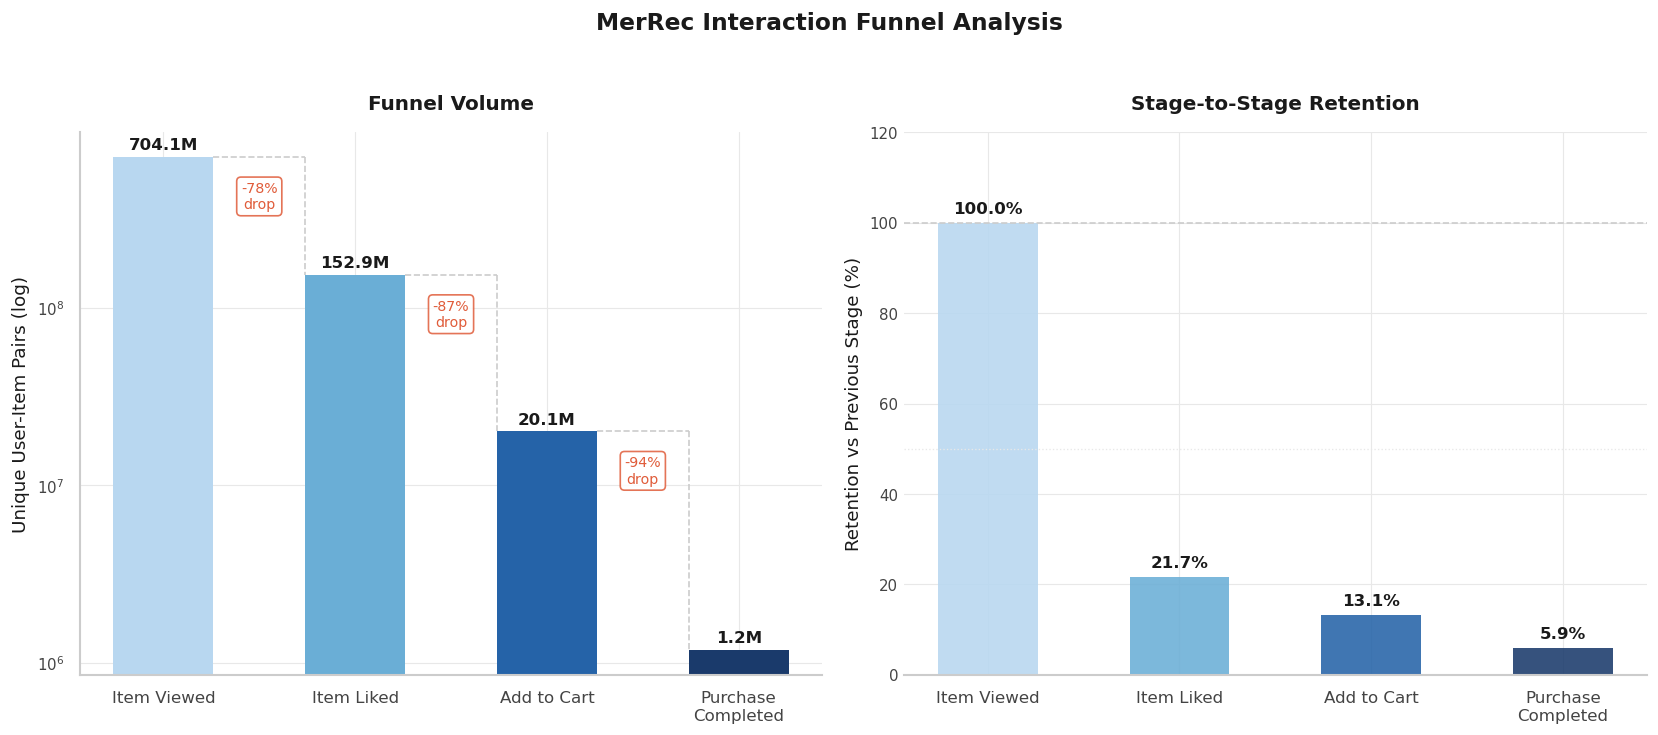

  saved → eda_outputs/05b_funnel_dropoff.png


In [9]:
# ── 6b. Funnel drop-off ───────────────────────────────────────────────────────
funnel = con.execute("""
    SELECT
        APPROX_COUNT_DISTINCT(CONCAT_WS(',',
            CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR)))
            FILTER (WHERE event_id = 'item_view')             AS views,
        APPROX_COUNT_DISTINCT(CONCAT_WS(',',
            CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR)))
            FILTER (WHERE event_id = 'item_like')             AS likes,
        APPROX_COUNT_DISTINCT(CONCAT_WS(',',
            CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR)))
            FILTER (WHERE event_id = 'item_add_to_cart_tap')  AS carts,
        APPROX_COUNT_DISTINCT(CONCAT_WS(',',
            CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR)))
            FILTER (WHERE event_id = 'buy_comp')              AS purchases
    FROM merrec
""").df()

stages     = ["Item Viewed", "Item Liked", "Add to Cart", "Purchase\nCompleted"]
funnel_vals = [
    funnel["views"].iloc[0],
    funnel["likes"].iloc[0],
    funnel["carts"].iloc[0],
    funnel["purchases"].iloc[0],
]
retention = [1.0] + [
    funnel_vals[i] / funnel_vals[i - 1]
    for i in range(1, len(funnel_vals))
]
drop      = [1.0 - r for r in retention]
bar_colors = ["#B8D7F0", "#6AAED6", "#2563A8", "#1A3A6B"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("MerRec Interaction Funnel Analysis",
             fontsize=14, fontweight="bold", y=1.02)

# ── Left: waterfall funnel ────────────────────────────────────────────────────
ax = axes[0]
bar_w = 0.52
x     = np.arange(len(stages))

bars = ax.bar(x, funnel_vals, width=bar_w,
              color=bar_colors, edgecolor="none")

# Connector lines between bars
for i in range(len(stages) - 1):
    y_top = funnel_vals[i]
    y_bot = funnel_vals[i + 1]
    x_right = x[i] + bar_w / 2
    x_left  = x[i + 1] - bar_w / 2
    ax.plot([x_right, x_left], [y_top, y_top],
            color="#CCCCCC", linewidth=1.0, linestyle="--")
    ax.plot([x_left,  x_left], [y_top, y_bot],
            color="#CCCCCC", linewidth=1.0, linestyle="--")

# Value labels above bars
for bar, val in zip(bars, funnel_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 1.06,
            f"{val/1e6:.1f}M",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1A1A1A")

# Drop-off labels between stages
for i in range(1, len(stages)):
    mid_x = (x[i - 1] + x[i]) / 2
    mid_y = funnel_vals[i - 1] * 0.6
    pct   = drop[i] * 100
    ax.text(mid_x, mid_y,
            f"-{pct:.0f}%\ndrop",
            ha="center", va="center",
            fontsize=8.5, color="#E05C3A",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#E05C3A",
                      alpha=0.85))

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=10)
ax.set_ylabel("Unique User-Item Pairs (log)", fontsize=11)
ax.set_title("Funnel Volume", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
ax.set_axisbelow(True)

# ── Right: retention rate bar chart ──────────────────────────────────────────
ax2 = axes[1]
ret_pct = [r * 100 for r in retention]

ret_colors = bar_colors 

b2 = ax2.bar(x, ret_pct, width=bar_w,
             color=ret_colors, edgecolor="none", alpha=0.88)

ax2.axhline(100, color="#CCCCCC", linewidth=1.0, linestyle="--")
ax2.axhline(50,  color="#E8E8E8", linewidth=0.8, linestyle=":")

# Value labels
for bar, val in zip(b2, ret_pct):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + 1.5,
             f"{val:.1f}%",
             ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A1A1A")

ax2.set_xticks(x)
ax2.set_xticklabels(stages, fontsize=10)
ax2.set_ylabel("Retention vs Previous Stage (%)", fontsize=11)
ax2.set_title("Stage-to-Stage Retention", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 120)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(axis="y", length=0)
ax2.yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
ax2.set_axisbelow(True)


plt.tight_layout()
save("05b_funnel_dropoff")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

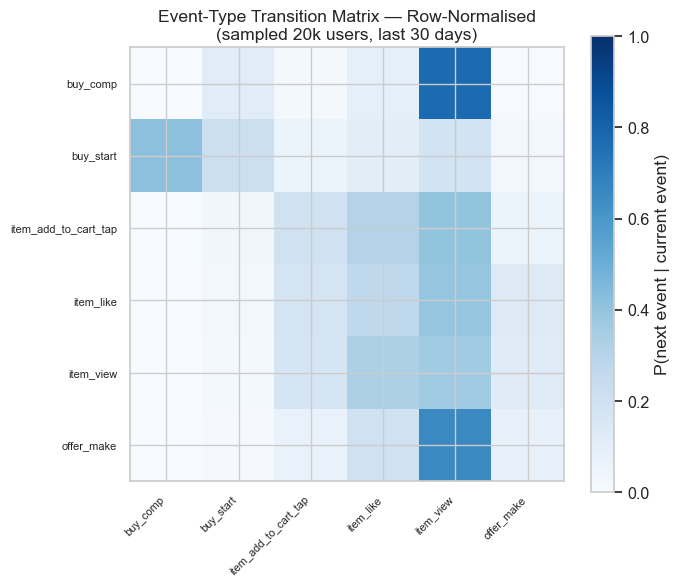

  ✓ saved → eda_outputs/05c_event_transition_matrix.png


In [9]:
# ── 6c. Event-type transition matrix ─────────────────────────────────────────
#
# Row-normalised to conditional probabilities P(next event | current event).
# Sampled on 20,000 users from the last 30 days to remain memory-efficient.

event_trans = con.execute("""
    WITH recent_bounds AS (
        SELECT MAX(stime) - INTERVAL '30 days' AS start FROM merrec
    ),
    sampled_users AS (
        SELECT user_id
        FROM merrec, recent_bounds
        WHERE merrec.stime >= recent_bounds.start
        GROUP BY user_id ORDER BY RANDOM() LIMIT 20000
    ),
    ordered AS (
        SELECT user_id, event_id,
               LEAD(event_id) OVER (PARTITION BY user_id ORDER BY stime) AS next_event
        FROM merrec
        WHERE user_id IN (SELECT user_id FROM sampled_users)
    )
    SELECT event_id AS from_event, next_event AS to_event,
           APPROX_COUNT_DISTINCT(user_id) AS cnt
    FROM ordered
    WHERE next_event IS NOT NULL
    GROUP BY from_event, to_event
""").df()

unique_events = sorted(set(event_trans["from_event"]) | set(event_trans["to_event"]))
eidx = {e: i for i, e in enumerate(unique_events)}
mat  = np.zeros((len(unique_events), len(unique_events)))
for _, row in event_trans.iterrows():
    f, t = row["from_event"], row["to_event"]
    if f in eidx and t in eidx:
        mat[eidx[f], eidx[t]] = row["cnt"]

row_sums = mat.sum(axis=1, keepdims=True)
mat_norm = np.divide(mat, row_sums, where=row_sums > 0)

n = len(unique_events)
fig, ax = plt.subplots(figsize=(max(7, n), max(6, n - 1)))
im = ax.imshow(mat_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(unique_events, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(unique_events, fontsize=8)
plt.colorbar(im, ax=ax, label="P(next event | current event)")
ax.set_title("Event-Type Transition Matrix — Row-Normalised\n(sampled 20k users, last 30 days)")
save("05c_event_transition_matrix")


---
## 7. Category Hierarchy Analysis




FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

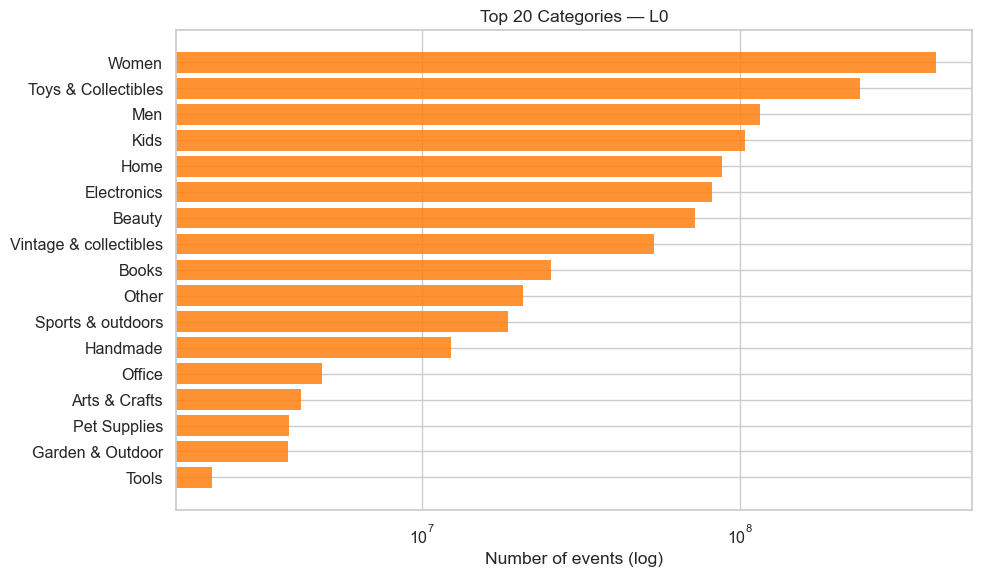

  ✓ saved → eda_outputs/06_top_categories_L0.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

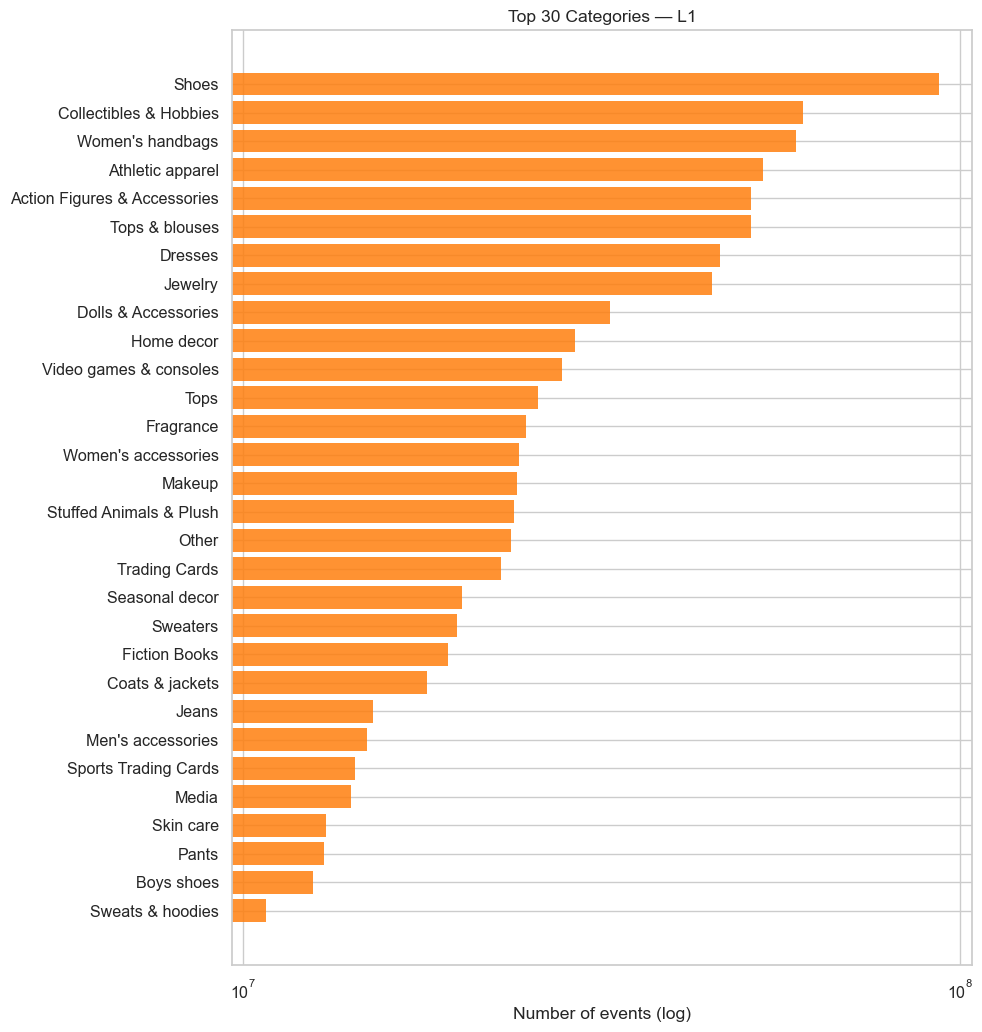

  ✓ saved → eda_outputs/06_top_categories_L1.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

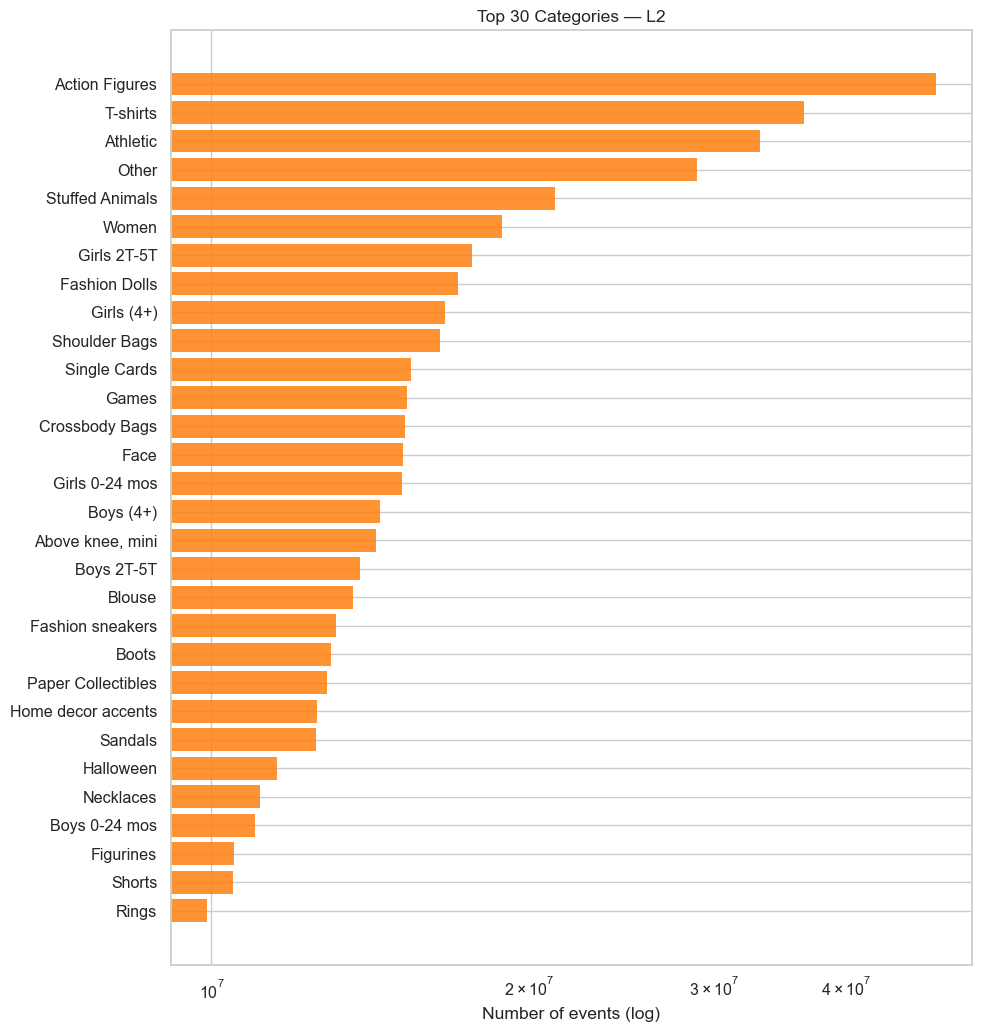

  ✓ saved → eda_outputs/06_top_categories_L2.png


In [10]:
# ── 7a. Top categories at each hierarchy level ───────────────────────────────
for level, col, topk in [("L0", "c0_name", 20), ("L1", "c1_name", 30), ("L2", "c2_name", 30)]:
    cat_df = con.execute(f"""
        SELECT {col}, COUNT(*) AS cnt
        FROM merrec
        WHERE {col} IS NOT NULL
        GROUP BY {col}
        ORDER BY cnt DESC
        LIMIT {topk}
    """).df()

    fig, ax = plt.subplots(figsize=(10, max(5, len(cat_df) * 0.35)))
    ax.barh(cat_df[col][::-1], cat_df["cnt"][::-1],
            color=PALETTE[1], edgecolor="none", alpha=0.85)
    ax.set(xscale="log", xlabel="Number of events (log)",
           title=f"Top {topk} Categories — {level}")
    save(f"06_top_categories_{level}")


In [ ]:
# ── 7b. Category-to-category transition matrix (L0, top-10) ──────────────────
top10_cats = con.execute("""
    SELECT c0_name FROM (
        SELECT c0_name, COUNT(*) AS cnt
        FROM merrec WHERE c0_name IS NOT NULL
        GROUP BY c0_name ORDER BY cnt DESC LIMIT 10
    )
""").df()["c0_name"].tolist()

escaped  = [c.replace("'", "''") for c in top10_cats]
cats_sql = "(" + ", ".join(f"'{c}'" for c in escaped) + ")"

cat_trans = con.execute(f"""
    WITH recent_bounds AS (
        SELECT MAX(stime) - INTERVAL '90 days' AS start FROM merrec
    ),
    sampled_users AS (
        SELECT user_id
        FROM merrec, recent_bounds
        WHERE merrec.c0_name IN {cats_sql}
          AND merrec.stime >= recent_bounds.start
        GROUP BY user_id ORDER BY RANDOM() LIMIT 20000
    ),
    ordered AS (
        SELECT user_id, c0_name,
               LEAD(c0_name) OVER (PARTITION BY user_id ORDER BY stime) AS next_cat
        FROM merrec
        WHERE user_id IN (SELECT user_id FROM sampled_users)
          AND c0_name IN {cats_sql}
    )
    SELECT c0_name AS from_cat, next_cat AS to_cat, COUNT(*) AS cnt
    FROM ordered WHERE next_cat IS NOT NULL
    GROUP BY c0_name, next_cat
""").df()

cidx = {{c: i for i, c in enumerate(top10_cats)}}
cmat = np.zeros((len(top10_cats), len(top10_cats)))
for _, row in cat_trans.iterrows():
    f, t = row["from_cat"], row["to_cat"]
    if f in cidx and t in cidx:
        cmat[cidx[f], cidx[t]] = row["cnt"]

crow     = cmat.sum(axis=1, keepdims=True)
cmat_norm = np.divide(cmat, crow, where=crow > 0)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cmat_norm, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(top10_cats))); ax.set_yticks(range(len(top10_cats)))
ax.set_xticklabels(top10_cats, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(top10_cats, fontsize=8)
plt.colorbar(im, ax=ax, label="P(next category | current category)")
ax.set_title("Category Transition Matrix — Top-10 L0\n(row-normalised, sampled last 90 days)")
save("06b_category_transition_matrix")


---
## 8. Temporal Patterns

Temporal analysis reveals whether user and item activity is stationary or drifting — a prerequisite for deciding whether time-aware features and models are necessary.



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

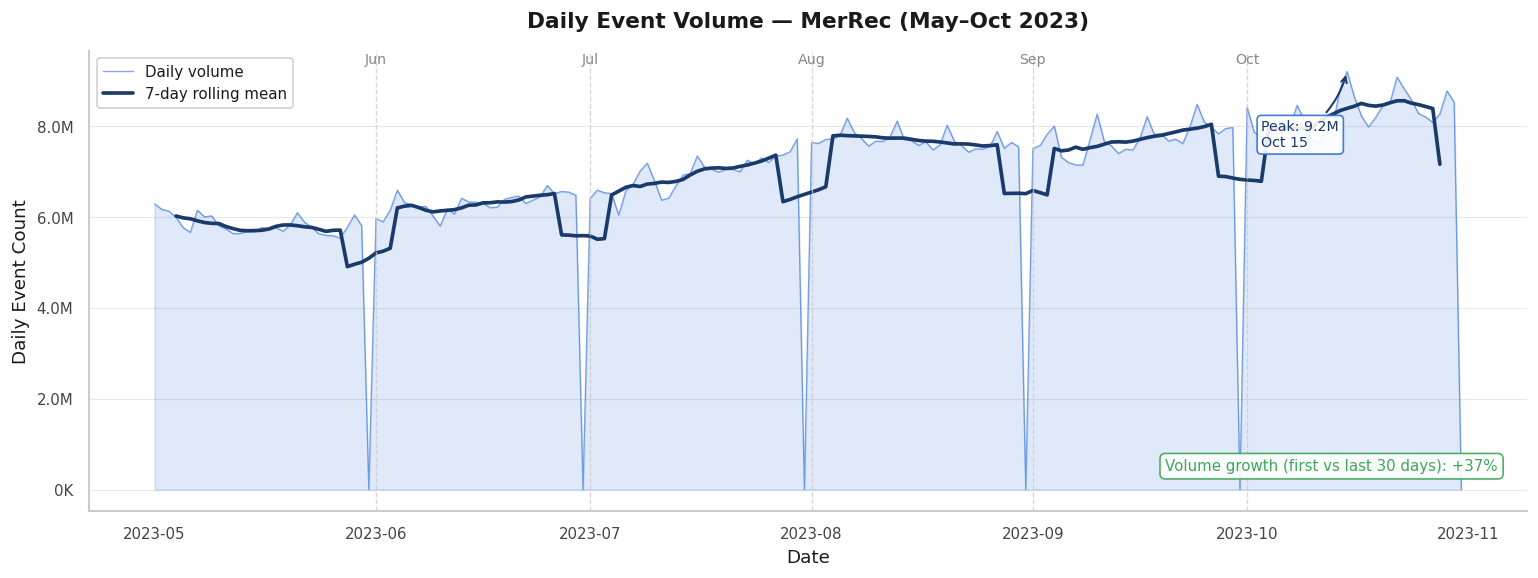

  saved → eda_outputs/07a_daily_event_volume.png


In [ ]:
# ── 8a. Daily event volume ────────────────────────────────────────────────────
daily_vol = con.execute("""
    SELECT DATE(stime) AS day, COUNT(*) AS num_events
    FROM merrec GROUP BY day ORDER BY day
""").df()
daily_vol["day"] = pd.to_datetime(daily_vol["day"])

# 7-day rolling average for trend line
daily_vol["rolling7"] = daily_vol["num_events"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Shaded area under raw volume
ax.fill_between(daily_vol["day"], daily_vol["num_events"],
                alpha=0.15, color="#2E6FD9")

# Raw daily line
ax.plot(daily_vol["day"], daily_vol["num_events"],
        linewidth=0.8, color="#2E6FD9", alpha=0.6, label="Daily volume")

# 7-day rolling trend
ax.plot(daily_vol["day"], daily_vol["rolling7"],
        linewidth=2.2, color="#1A3A6B", label="7-day rolling mean")

# Month boundary lines
months = daily_vol["day"].dt.to_period("M").unique()
for period in months[1:]:
    month_start = period.to_timestamp()
    ax.axvline(month_start, color="#CCCCCC", linewidth=0.8,
               linestyle="--", alpha=0.8)
    ax.text(month_start, daily_vol["num_events"].max() * 1.02,
            month_start.strftime("%b"),
            ha="center", fontsize=8.5, color="#888888")

# Peak annotation
peak_idx = daily_vol["num_events"].idxmax()
peak_day = daily_vol.loc[peak_idx, "day"]
peak_val = daily_vol.loc[peak_idx, "num_events"]
ax.annotate(
    f"Peak: {peak_val/1e6:.1f}M\n{peak_day.strftime('%b %d')}",
    xy=(peak_day, peak_val),
    xytext=(peak_day - pd.Timedelta(days=12), peak_val * 0.82),
    fontsize=8.5, color="#1A3A6B",
    arrowprops=dict(arrowstyle="->", color="#1A3A6B",
                    lw=1.2, connectionstyle="arc3,rad=0.2"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="#2E6FD9", alpha=0.9)
)


first_mean = daily_vol.head(30)["num_events"].mean()
last_mean  = daily_vol.tail(30)["num_events"].mean()
growth_pct = (last_mean - first_mean) / first_mean * 100
ax.text(0.98, 0.08,
        f"Volume growth (first vs last 30 days): +{growth_pct:.0f}%",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color="#3DA854",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="#3DA854", alpha=0.9))

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Daily Event Count", fontsize=11)
ax.set_title("Daily Event Volume — MerRec (May–Oct 2023)",
             fontsize=13, fontweight="bold", pad=14)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6
                          else f"{x/1e3:.0f}K"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

plt.tight_layout()
save("07a_daily_event_volume")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

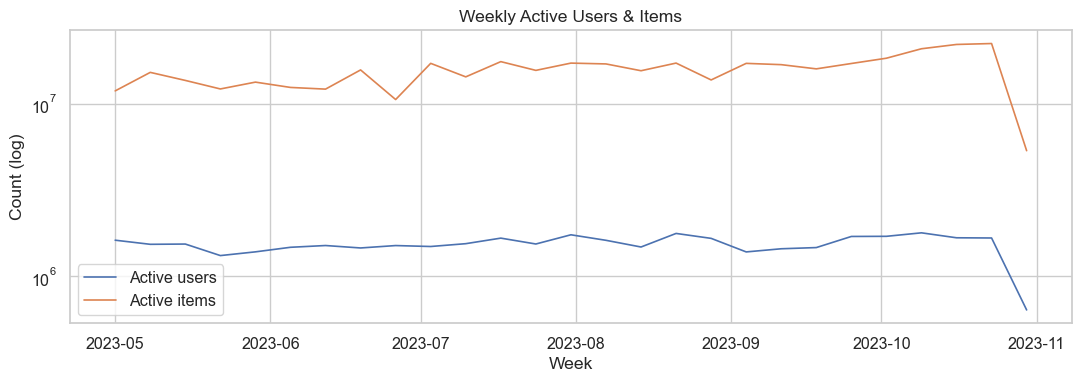

  ✓ saved → eda_outputs/07b_weekly_active_users_items.png


In [13]:
# ── 8b. Weekly active users & items ──────────────────────────────────────────
weekly = con.execute("""
    SELECT
        DATE_TRUNC('week', stime)           AS week,
        APPROX_COUNT_DISTINCT(user_id)      AS users,
        APPROX_COUNT_DISTINCT(item_id)      AS items
    FROM merrec GROUP BY week ORDER BY week
""").df()
weekly["week"] = pd.to_datetime(weekly["week"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weekly["week"], weekly["users"], label="Active users", linewidth=1.2)
ax.plot(weekly["week"], weekly["items"], label="Active items",  linewidth=1.2)
ax.set(yscale="log", xlabel="Week", ylabel="Count (log)",
       title="Weekly Active Users & Items")
ax.legend()
save("07b_weekly_active_users_items")


In [ ]:
# ── 8c. Category share drift (monthly, top-6 L1) ─────────────────────────────
top6_l1 = con.execute("""
    SELECT c1_name FROM (
        SELECT c1_name, COUNT(*) AS cnt
        FROM merrec WHERE c1_name IS NOT NULL
        GROUP BY c1_name ORDER BY cnt DESC LIMIT 6
    )
""").df()["c1_name"].tolist()

esc6   = [c.replace("'", "''") for c in top6_l1]
cats6  = "(" + ", ".join(f"'{c}'" for c in esc6) + ")"

cat_monthly = con.execute(f"""
    SELECT DATE_TRUNC('month', stime) AS month, c1_name, COUNT(*) AS cnt
    FROM merrec WHERE c1_name IN {cats6}
    GROUP BY month, c1_name ORDER BY month
""").df()
cat_monthly["month"] = pd.to_datetime(cat_monthly["month"])

pivot = cat_monthly.pivot_table(
    index="month", columns="c1_name", values="cnt", fill_value=0
).div(lambda df: df.sum(axis=1), axis=0)

# Manual normalisation (avoids lambda in older pandas)
pivot = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns)
ax.set(xlabel="Month", ylabel="Category share",
       title="Category Share Drift Over Time (Top-6 L1 Categories)")
ax.legend(loc="upper right", fontsize=8)
save("07c_category_share_drift")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

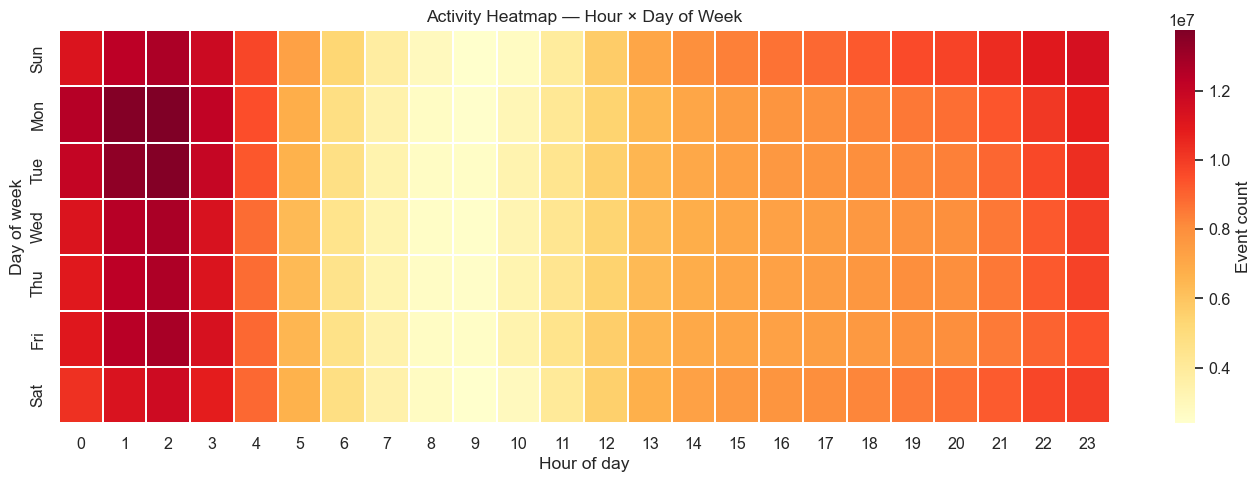

  ✓ saved → eda_outputs/07d_activity_heatmap_hour_dow.png


In [16]:
# ── 8d. Hour-of-day × Day-of-week activity heatmap ───────────────────────────
heatmap_df = con.execute("""
    SELECT
        DAYOFWEEK(stime) AS dow,
        HOUR(stime)      AS hour,
        COUNT(*)         AS cnt
    FROM merrec
    GROUP BY dow, hour
""").df()

pivot_hm = heatmap_df.pivot_table(
    index="dow", columns="hour", values="cnt", fill_value=0
)
dow_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_hm, cmap="YlOrRd", ax=ax,
            linewidths=0.3, linecolor="white",
            yticklabels=dow_labels,
            cbar_kws={"label": "Event count"})
ax.set(xlabel="Hour of day", ylabel="Day of week",
       title="Activity Heatmap — Hour × Day of Week")
save("07d_activity_heatmap_hour_dow")


---
## 9. Price Distribution

Price is a key item-level feature. Its distribution informs feature scaling decisions and reveals segment structure across product categories. Price data is only available for a subset of interactions (see missing-value audit in Section 2).


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

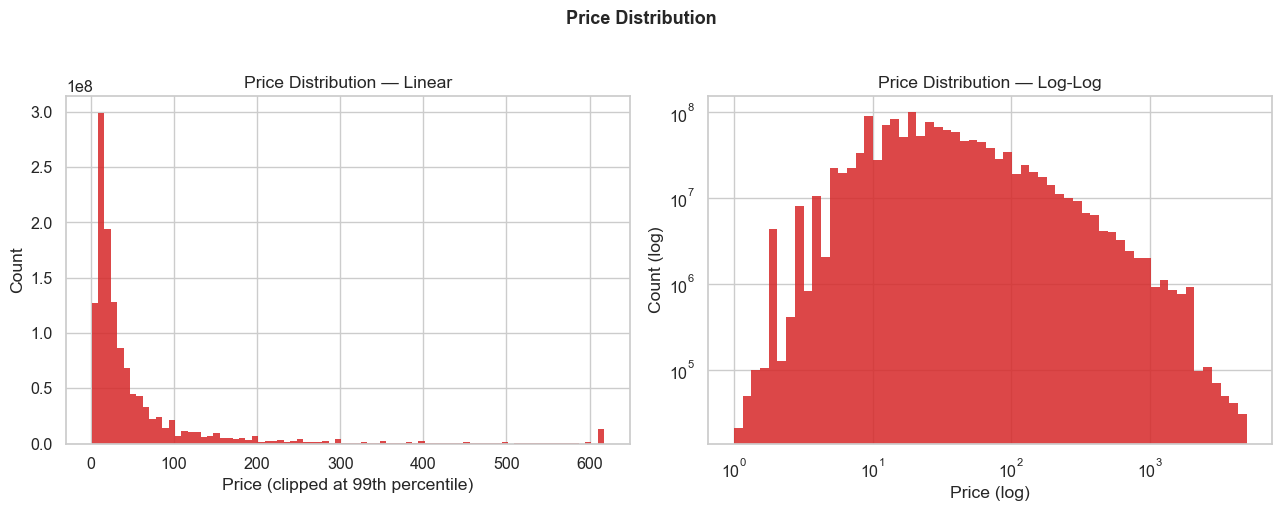

  ✓ saved → eda_outputs/08_price_distribution.png


: 

In [ ]:
# ── 9a. Global price distribution ────────────────────────────────────────────
price_df = con.execute("""
    SELECT price FROM merrec WHERE price IS NOT NULL AND price > 0
""").df()

prices = price_df["price"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(prices.clip(max=np.percentile(prices, 99)),
             bins=80, color=PALETTE[3], edgecolor="none", alpha=0.85)
axes[0].set(xlabel="Price (clipped at 99th percentile)",
            ylabel="Count",
            title="Price Distribution — Linear")

axes[1].hist(prices,
             bins=np.logspace(np.log10(prices.min() + 1e-3), np.log10(prices.max()), 60),
             color=PALETTE[3], edgecolor="none", alpha=0.85)
axes[1].set(xscale="log", yscale="log",
            xlabel="Price (log)",
            ylabel="Count (log)",
            title="Price Distribution — Log-Log")

fig.suptitle("Price Distribution", fontsize=13, fontweight="bold", y=1.02)
save("08_price_distribution")


In [ ]:
# ── 9b. Price by top-5 L0 category ───────────────────────────────────────────
top5_l0 = con.execute("""
    SELECT c0_name FROM (
        SELECT c0_name, COUNT(*) AS cnt
        FROM merrec WHERE c0_name IS NOT NULL
        GROUP BY c0_name ORDER BY cnt DESC LIMIT 5
    )
""").df()["c0_name"].tolist()

esc5   = [c.replace("'", "''") for c in top5_l0]
cats5  = "(" + ", ".join(f"'{c}'" for c in esc5) + ")"

price_cat = con.execute(f"""
    SELECT c0_name, price
    FROM merrec
    WHERE c0_name IN {cats5} AND price IS NOT NULL AND price > 0
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
price_cat.boxplot(column="price", by="c0_name", ax=ax, sym="",
                  medianprops=dict(color="crimson", linewidth=2))
ax.set(yscale="log", xlabel="Category (L0)",
       ylabel="Price (log)", title="Price by Top-5 L0 Categories")
plt.suptitle("")
plt.xticks(rotation=20, ha="right")
save("08b_price_by_category")


---
## 10. Sparsity, Gini & Cold-Start Diagnostics

### Sparsity
The interaction matrix has dimensions $|\text{users}| \times |\text{items}|$. Sparsity is defined as:

$$\text{sparsity} = 1 - \frac{|\text{observed interactions}|}{|\text{users}| \times |\text{items}|}$$

In C2C datasets, sparsity typically exceeds 99.9%. This directly determines the feasibility of neighbourhood-based vs factorisation-based models.

### Gini Coefficient
The Gini coefficient measures interaction inequality on a scale of 0 (perfect equality) to 1 (one entity receives all interactions). A high Gini on the item side confirms the long-tail structure and informs how many items can realistically receive quality representations.

### Cold-Start
Cold-start users and items (those with ≤ $k$ interactions) are likely to receive poor latent representations. Quantifying their prevalence at multiple thresholds supports the research question on category-aware cold-start mitigation.


In [ ]:
events_per_user = con.execute("""
    SELECT user_id, COUNT(*) AS event_count
    FROM merrec
    GROUP BY user_id
""").fetch_arrow_table()
ec = np.array(events_per_user["event_count"])


In [ ]:
events_per_item = con.execute("""
    SELECT item_id, COUNT(*) AS event_count
    FROM merrec
    GROUP BY item_id
""").fetch_arrow_table()
ic = np.array(events_per_item["event_count"])

In [15]:
# ── 10a. Gini coefficients & Lorenz curves ────────────────────────────────────
def gini(arr: np.ndarray) -> float:
    """Gini coefficient of a 1-D non-negative array."""
    arr = np.sort(arr.astype(float))
    n   = len(arr)
    idx = np.arange(1, n + 1)
    return float((2 * idx - n - 1).dot(arr) / (n * arr.sum()))

def lorenz(arr):
    arr = np.sort(arr.astype(float))
    cum = np.cumsum(arr)
    cum = np.insert(cum, 0, 0) / cum[-1]
    pop = np.linspace(0, 1, len(cum))
    return pop, cum


user_gini = gini(ec)
item_gini = gini(ic)
n_users   = len(ec)
n_items   = len(ic)
n_events  = int(ec.sum())
sparsity  = 1.0 - (n_events / (n_users * n_items))

print(f"User-side Gini  : {user_gini:.4f}")
print(f"Item-side Gini  : {item_gini:.4f}")
print(f"Matrix sparsity : {sparsity:.8f}")
print(f"Users           : {n_users:,}")
print(f"Items           : {n_items:,}")
print(f"Events          : {n_events:,}")


User-side Gini  : 0.8390
Item-side Gini  : 0.6631
Matrix sparsity : 0.99999724
Users           : 5,566,055
Items           : 82,614,392
Events          : 1,268,092,738


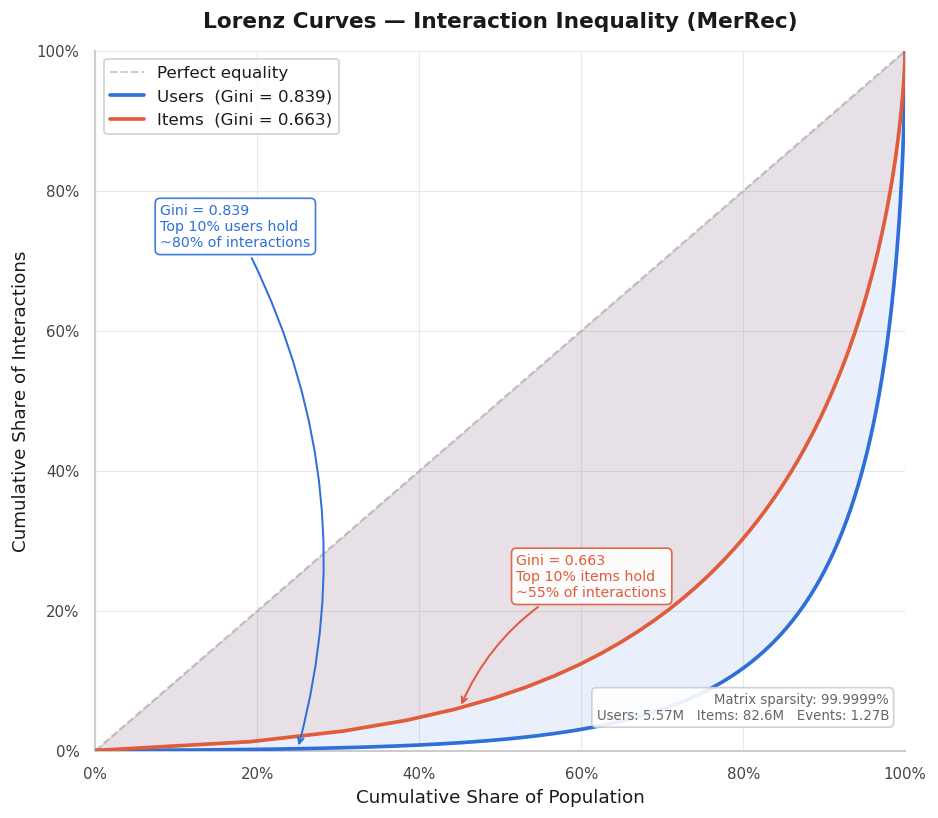

  saved → eda_outputs/09_lorenz_gini.png


In [16]:
# ── 10a. Lorenz curves ────────────────────────────────────────────────────────
pop_u, cum_u = lorenz(ec)
pop_i, cum_i = lorenz(ic)

fig, ax = plt.subplots(figsize=(8, 7))

# Equality line
ax.plot([0, 1], [0, 1], color="#CCCCCC", linewidth=1.2,
        linestyle="--", label="Perfect equality", zorder=1)

# Shaded inequality areas
ax.fill_between(pop_u, cum_u, pop_u,
                alpha=0.10, color="#2E6FD9")
ax.fill_between(pop_i, cum_i, pop_i,
                alpha=0.10, color="#E05C3A")

# Lorenz curves
ax.plot(pop_u, cum_u, color="#2E6FD9", linewidth=2.2,
        label=f"Users  (Gini = 0.839)", zorder=3)
ax.plot(pop_i, cum_i, color="#E05C3A", linewidth=2.2,
        label=f"Items  (Gini = 0.663)", zorder=3)

# ── Gini annotation badges ────────────────────────────────────────────────────
# User badge — point at the curve midpoint
ax.annotate(
    "Gini = 0.839\nTop 10% users hold\n~80% of interactions",
    xy=(0.25, cum_u[int(0.25 * len(cum_u))]),
    xytext=(0.08, 0.72),
    fontsize=8.5, color="#2E6FD9",
    arrowprops=dict(arrowstyle="->", color="#2E6FD9",
                    lw=1.2, connectionstyle="arc3,rad=-0.2"),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor="#2E6FD9", alpha=0.92)
)

# Item badge
ax.annotate(
    "Gini = 0.663\nTop 10% items hold\n~55% of interactions",
    xy=(0.45, cum_i[int(0.45 * len(cum_i))]),
    xytext=(0.52, 0.22),
    fontsize=8.5, color="#E05C3A",
    arrowprops=dict(arrowstyle="->", color="#E05C3A",
                    lw=1.2, connectionstyle="arc3,rad=0.2"),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor="#E05C3A", alpha=0.92)
)

# ── Sparsity badge bottom right ───────────────────────────────────────────────
ax.text(0.98, 0.04,
        f"Matrix sparsity: 99.9999%\n"
        f"Users: 5.57M   Items: 82.6M   Events: 1.27B",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8, color="#666666",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="#CCCCCC", alpha=0.9))

ax.set_xlabel("Cumulative Share of Population", fontsize=11)
ax.set_ylabel("Cumulative Share of Interactions", fontsize=11)
ax.set_title("Lorenz Curves — Interaction Inequality (MerRec)",
             fontsize=13, fontweight="bold", pad=14)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, color="#E8E8E8", linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc="upper left", framealpha=0.9)

plt.tight_layout()
save("09_lorenz_gini")

In [11]:
# ── 10b. Long-tail threshold analysis ────────────────────────────────────────
print(f"{'Label':<10} {'Coverage':>10} {'Threshold':>12} {'Entities':>12} {'% of events':>14}")
print("-" * 60)
for label, counts_arr in [("Users", ec), ("Items", ic)]:
    total_int = counts_arr.sum()
    for pct in [0.80, 0.90, 0.95]:
        threshold = np.percentile(counts_arr, (1 - pct) * 100)
        heavy_n   = int((counts_arr >= threshold).sum())
        heavy_int = int(counts_arr[counts_arr >= threshold].sum())
        print(f"{label:<10} {pct*100:>9.0f}%  {threshold:>12.0f}  {heavy_n:>12,}  {heavy_int/total_int*100:>13.1f}%")


Label        Coverage    Threshold     Entities    % of events
------------------------------------------------------------
Users             80%             4     4,476,342           99.8%
Users             90%             2     5,065,802          100.0%
Users             95%             1     5,566,055          100.0%
Items             80%             2    67,028,960           98.8%
Items             90%             1    82,613,843          100.0%
Items             95%             1    82,613,843          100.0%


Cold-start users (≤ k interactions):


,k,n_users,pct
0,1,500253,8.987568
1,2,838528,15.065033
2,5,1502576,26.995349
3,10,2072961,37.242913
4,20,2653159,47.666777



Cold-start items (≤ k interactions):


,k,n_items,pct
0,1,15584884,18.864737
1,2,25109295,30.393568
2,5,40417881,48.923860
3,10,53391203,64.627429
4,20,65685927,79.509588


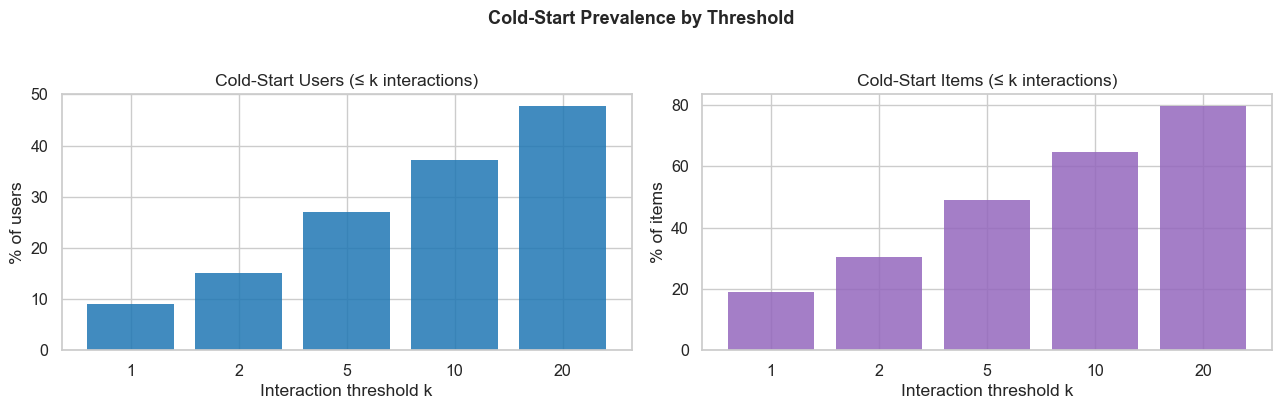

  ✓ saved → eda_outputs/10_cold_start_diagnostics.png


In [12]:
# ── 10c. Cold-start prevalence at multiple thresholds ─────────────────────────
thresholds = [1, 2, 5, 10, 20]
cold_user_rows = [(k, int((ec <= k).sum()), float((ec <= k).mean() * 100)) for k in thresholds]
cold_item_rows = [(k, int((ic <= k).sum()), float((ic <= k).mean() * 100)) for k in thresholds]

cold_user_df = pd.DataFrame(cold_user_rows, columns=["k", "n_users",  "pct"])
cold_item_df = pd.DataFrame(cold_item_rows, columns=["k", "n_items", "pct"])

print("Cold-start users (≤ k interactions):")
display(cold_user_df)
print("\nCold-start items (≤ k interactions):")
display(cold_item_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar([str(k) for k in thresholds], cold_user_df["pct"],
            color=PALETTE[0], edgecolor="none", alpha=0.85)
axes[0].set(xlabel="Interaction threshold k", ylabel="% of users",
            title="Cold-Start Users (≤ k interactions)")

axes[1].bar([str(k) for k in thresholds], cold_item_df["pct"],
            color=PALETTE[4], edgecolor="none", alpha=0.85)
axes[1].set(xlabel="Interaction threshold k", ylabel="% of items",
            title="Cold-Start Items (≤ k interactions)")

fig.suptitle("Cold-Start Prevalence by Threshold", fontsize=13, fontweight="bold", y=1.02)
save("10_cold_start_diagnostics")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

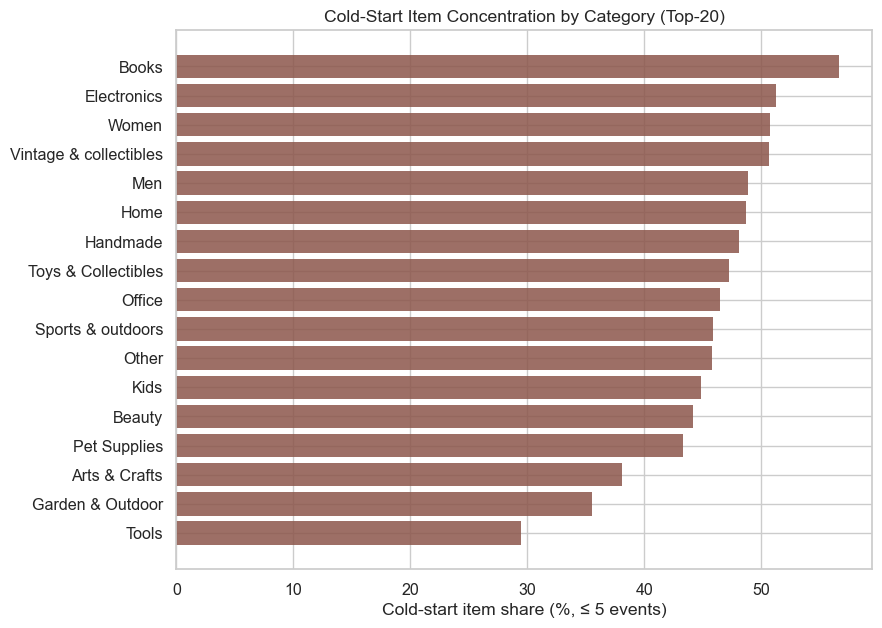

  ✓ saved → eda_outputs/10b_cold_start_by_category.png


In [4]:
# ── 10d. Cold-start concentration by L0 category ──────────────────────────────
#
# Do cold-start items cluster in particular categories?
# If yes, category context becomes a stronger cold-start signal for those segments.

item_cat_counts = con.execute("""
    SELECT item_id, c0_name, COUNT(*) AS event_count
    FROM merrec WHERE c0_name IS NOT NULL
    GROUP BY item_id, c0_name
""").df()

cold_items = set(item_cat_counts.loc[item_cat_counts["event_count"] <= 5, "item_id"])

category_cold_share = (
    item_cat_counts
    .assign(is_cold=lambda df: df["item_id"].isin(cold_items))
    .groupby("c0_name")["is_cold"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
category_cold_share.columns = ["c0_name", "cold_item_share"]

fig, ax = plt.subplots(figsize=(9, max(5, len(category_cold_share) * 0.38)))
ax.barh(category_cold_share["c0_name"][::-1],
        category_cold_share["cold_item_share"][::-1] * 100,
        color=PALETTE[5], edgecolor="none", alpha=0.85)
ax.set(xlabel="Cold-start item share (%, ≤ 5 events)",
       title="Cold-Start Item Concentration by Category (Top-20)")
save("10b_cold_start_by_category")
